In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import shutil

input_dir = "/kaggle/input/datasets/sridipbasu/ombria-code-and-data/OMBRIA-master" 

if not os.path.exists("/kaggle/working/OmbriaS1"):
    shutil.copytree(os.path.join(input_dir, "OmbriaS1"), "/kaggle/working/OmbriaS1")
    print("Copied OmbriaS1")
if not os.path.exists("/kaggle/working/OmbriaS2"):
    shutil.copytree(os.path.join(input_dir, "OmbriaS2"), "/kaggle/working/OmbriaS2")
    print("Copied OmbriaS2")


Copied OmbriaS1
Copied OmbriaS2


In [2]:
 

# Copy python files
for file in os.listdir(input_dir):
    if file.endswith(".py") or file == "requirements.txt":
        shutil.copy(os.path.join(input_dir, file), "/kaggle/working/")
        print(f"Copied {file} to working directory.")

# Verify files copied
!ls -la /kaggle/working

Copied test_checklist.py to working directory.
Copied train.py to working directory.
Copied metrics.py to working directory.
Copied main.py to working directory.
Copied requirements.txt to working directory.
Copied models.py to working directory.
Copied baselines.py to working directory.
Copied gee_parser.py to working directory.
total 84
drwxr-xr-x 5 root root  4096 May 26 14:10 .
drwxr-xr-x 5 root root  4096 May 26 14:09 ..
-rw-r--r-- 1 root root  1405 May 26 14:10 baselines.py
-rw-r--r-- 1 root root  4553 May 26 14:10 gee_parser.py
-rw-r--r-- 1 root root 17037 May 26 14:10 main.py
-rw-r--r-- 1 root root  2168 May 26 14:10 metrics.py
-rw-r--r-- 1 root root 10369 May 26 14:10 models.py
drwxr-xr-x 4 root root  4096 May 26 14:08 OmbriaS1
drwxr-xr-x 4 root root  4096 May 26 14:08 OmbriaS2
-rw-r--r-- 1 root root   113 May 26 14:10 requirements.txt
-rw-r--r-- 1 root root  5047 May 26 14:10 test_checklist.py
-rw-r--r-- 1 root root  3653 May 26 14:10 train.py
drwxr-xr-x 2 root root  4096 May

In [3]:
!python test_checklist.py

[Test T-DS-01] Checking tile size and channels...
S1 sample shape: (256, 256)
S2 sample shape: (256, 256, 3)
-> T-DS-01 Passed!
[Test T-DS-02] Checking split ratio (80/10/10)...
[GEE Info] Initializing Google Earth Engine connection for project: 'ombrianet-gee-4102'...
[GEE Info] Authenticating via environment credentials...
[GEE Info] GEE authentication successful. Active session established.
[GEE Split] Splitting dataset in OmbriaS1 with ratios (0.8, 0.1, 0.1) (seed=7, shuffle=True)...
[GEE Split] Split results: Train=675, Val=84, Test=85
-> T-DS-02 Passed!
[Test T-MD-01, T-MD-02, T-MD-03] Checking model parameters...
UNet parameters: 31032837
Bitemporal parameters: 10797637
Multimodal parameters: 18108101
-> T-MD-01, T-MD-02, T-MD-03 Passed!
[Test T-OPT-01] Checking optimizer and loss configuration...
Optimizer: Adam
Loss function: BCELoss
-> T-OPT-01 Passed!
[Test T-BASE-01] Checking Otsu/MNDWI sanity check...
Otsu mask unique values: [0 1]
-> T-BASE-01 Passed!
[Test T-BASE-02] Che

In [4]:
!python main.py --mode train --model multimodal --epochs 50 --batch_size 8 --data_dir_s1 OmbriaS1 --data_dir_s2 OmbriaS2

Using device: cuda
[Deep Learning] Starting training pipeline for multimodal model...
Epoch 1/50 - Train Loss: 0.5930, Train Acc: 0.6888 - Val Loss: 0.4207, Val Acc: 0.7886
--> Saved best model checkpoint to best_model.pth
Epoch 2/50 - Train Loss: 0.4109, Train Acc: 0.8115 - Val Loss: 0.3640, Val Acc: 0.8404
--> Saved best model checkpoint to best_model.pth
Epoch 3/50 - Train Loss: 0.3589, Train Acc: 0.8413 - Val Loss: 0.3482, Val Acc: 0.8424
--> Saved best model checkpoint to best_model.pth
Epoch 4/50 - Train Loss: 0.3574, Train Acc: 0.8426 - Val Loss: 0.3410, Val Acc: 0.8510
--> Saved best model checkpoint to best_model.pth
Epoch 5/50 - Train Loss: 0.3550, Train Acc: 0.8449 - Val Loss: 0.3384, Val Acc: 0.8520
--> Saved best model checkpoint to best_model.pth
Epoch 6/50 - Train Loss: 0.3453, Train Acc: 0.8506 - Val Loss: 0.3358, Val Acc: 0.8548
--> Saved best model checkpoint to best_model.pth
Epoch 7/50 - Train Loss: 0.3334, Train Acc: 0.8546 - Val Loss: 0.3329, Val Acc: 0.8571
--> S

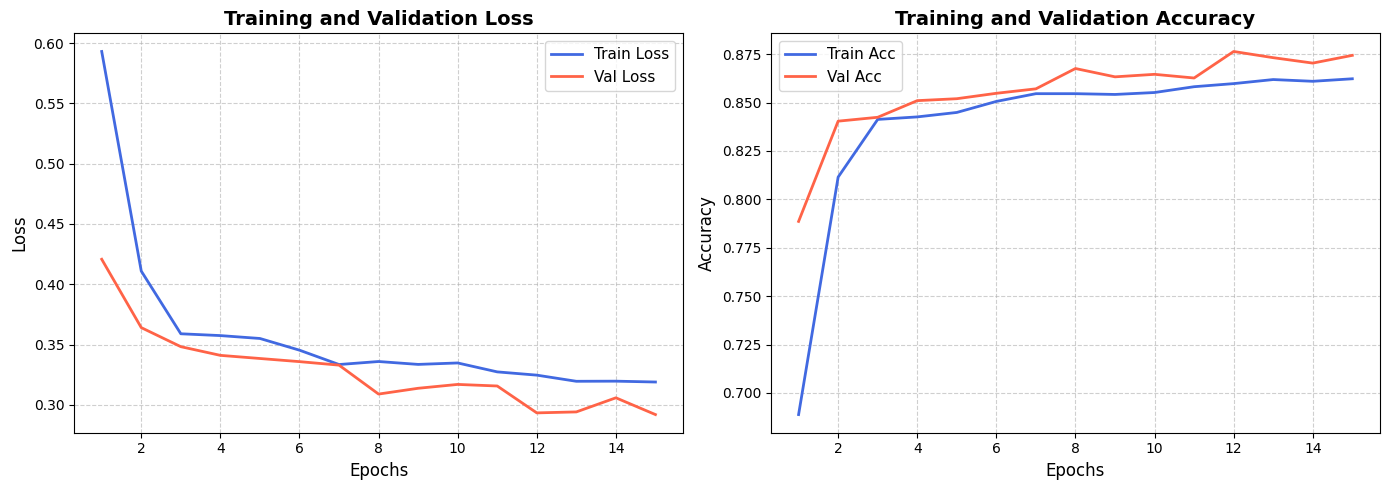

In [5]:

import matplotlib.pyplot as plt

# Reconstruct history from the 15 completed epochs
history = {
    "train_loss": [
        0.5930, 0.4109, 0.3589, 0.3574, 0.3550, 0.3453, 0.3334, 0.3359, 
        0.3335, 0.3347, 0.3273, 0.3246, 0.3195, 0.3196, 0.3189
    ],
    "train_acc":  [
        0.6888, 0.8115, 0.8413, 0.8426, 0.8449, 0.8506, 0.8546, 0.8546, 
        0.8542, 0.8552, 0.8582, 0.8598, 0.8619, 0.8610, 0.8623
    ],
    "val_loss":   [
        0.4207, 0.3640, 0.3482, 0.3410, 0.3384, 0.3358, 0.3329, 0.3089, 
        0.3137, 0.3169, 0.3156, 0.2933, 0.2941, 0.3058, 0.2919
    ],
    "val_acc":    [
        0.7886, 0.8404, 0.8424, 0.8510, 0.8520, 0.8548, 0.8571, 0.8676, 
        0.8633, 0.8646, 0.8627, 0.8764, 0.8732, 0.8704, 0.8744
    ]
}

# Plot configuration
epochs = len(history["train_loss"])
epoch_range = range(1, epochs + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Subplot
ax[0].plot(epoch_range, history["train_loss"], label="Train Loss", color="royalblue", linewidth=2)
ax[0].plot(epoch_range, history["val_loss"], label="Val Loss", color="tomato", linewidth=2)
ax[0].set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Epochs", fontsize=12)
ax[0].set_ylabel("Loss", fontsize=12)
ax[0].legend(fontsize=11)
ax[0].grid(True, linestyle="--", alpha=0.6)

# 2. Accuracy Subplot
ax[1].plot(epoch_range, history["train_acc"], label="Train Acc", color="royalblue", linewidth=2)
ax[1].plot(epoch_range, history["val_acc"], label="Val Acc", color="tomato", linewidth=2)
ax[1].set_title("Training and Validation Accuracy", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Epochs", fontsize=12)
ax[1].set_ylabel("Accuracy", fontsize=12)
ax[1].legend(fontsize=11)
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()


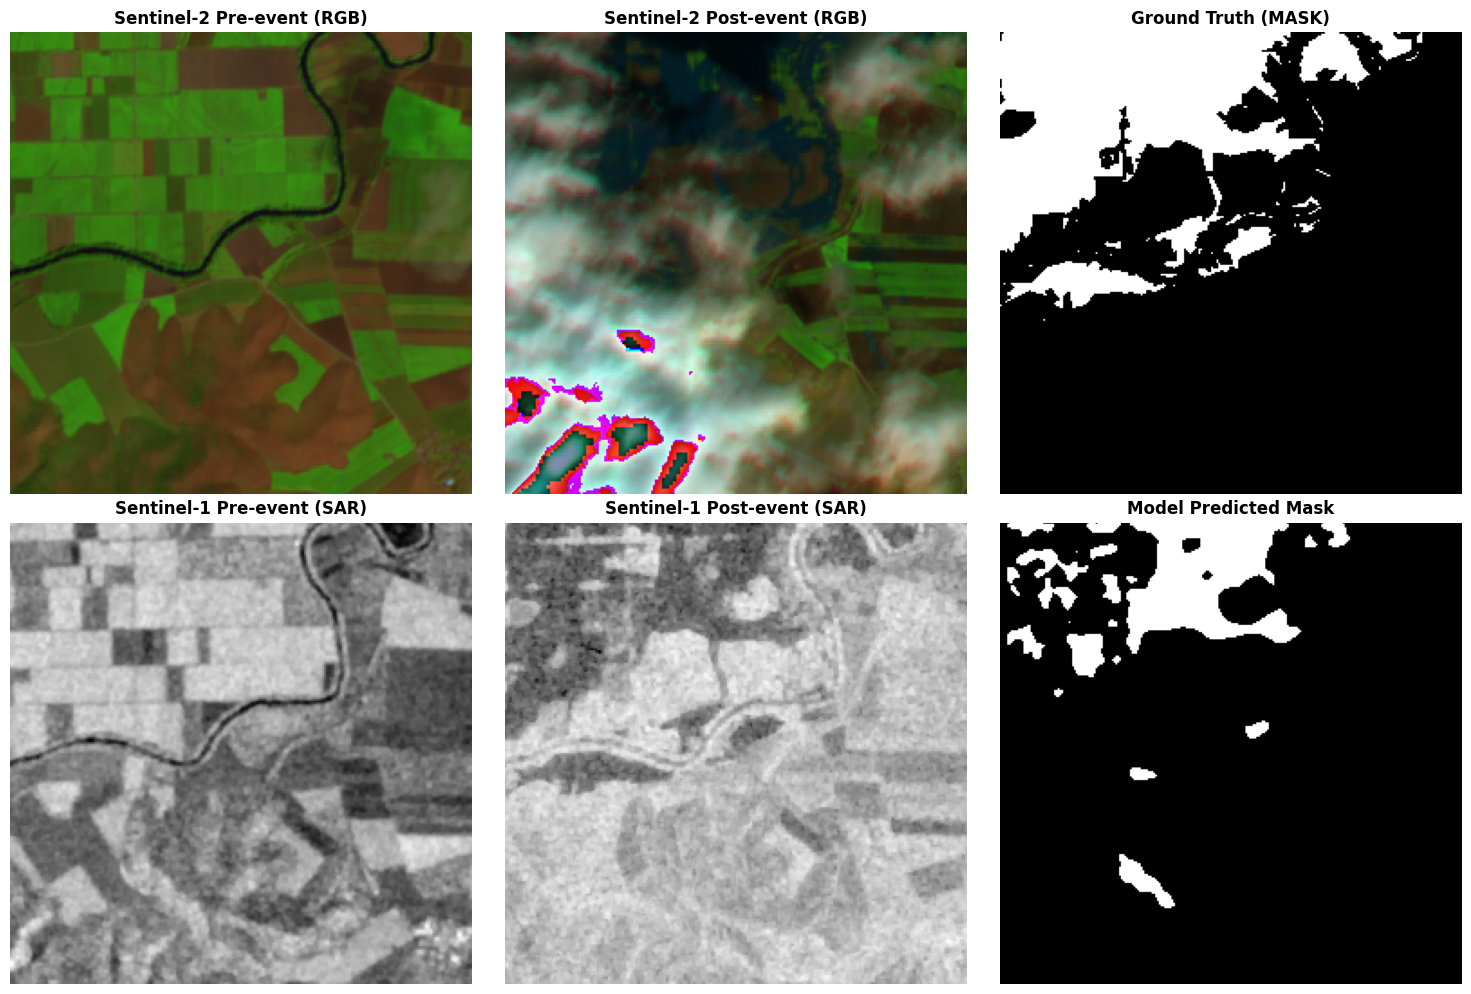

In [6]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from main import OmbriaDataset
from models import MultimodalOmbriaNet
from IPython.display import Image, display

# 1. Set device and load the test dataset
device = "cuda" if torch.cuda.is_available() else "cpu"
test_dataset = OmbriaDataset("OmbriaS2", "OmbriaS1", split="test", mode="multimodal")

# 2. Pick a test sample index to visualize (e.g., index 10)
sample_idx = 10
inputs, mask = test_dataset[sample_idx]

# 3. Load the model and best checkpoint weights
model = MultimodalOmbriaNet(in_ch_s2=3, in_ch_s1=1)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# 4. Make prediction
with torch.no_grad():
    # Wrap inputs in batches and send to device
    inputs_device = [x.unsqueeze(0).to(device) for x in inputs]
    output = model(*inputs_device)
    pred_mask = (output > 0.5).cpu().numpy().squeeze()

# 5. Extract individual bands for plotting
# inputs list: [s2_after, s2_before, s1_after, s1_before]
s2_after_img = inputs[0].numpy().transpose(1, 2, 0)   # RGB
s2_before_img = inputs[1].numpy().transpose(1, 2, 0)  # RGB
s1_after_img = inputs[2].numpy().squeeze()            # Grayscale (SAR)
s1_before_img = inputs[3].numpy().squeeze()           # Grayscale (SAR)
gt_mask = mask.numpy().squeeze()

# 6. Plot the 2x3 grid of all modalities, ground truth, and prediction
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Sentinel-2 & Ground Truth
axes[0, 0].imshow(s2_before_img)
axes[0, 0].set_title(f"Sentinel-2 Pre-event (RGB)", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(s2_after_img)
axes[0, 1].set_title(f"Sentinel-2 Post-event (RGB)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(gt_mask, cmap="gray")
axes[0, 2].set_title(f"Ground Truth (MASK)", fontsize=12, fontweight="bold")
axes[0, 2].axis("off")

# Row 2: Sentinel-1 & Model Prediction
axes[1, 0].imshow(s1_before_img, cmap="gray")
axes[1, 0].set_title(f"Sentinel-1 Pre-event (SAR)", fontsize=12, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(s1_after_img, cmap="gray")
axes[1, 1].set_title(f"Sentinel-1 Post-event (SAR)", fontsize=12, fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(pred_mask, cmap="gray")
axes[1, 2].set_title(f"Model Predicted Mask", fontsize=12, fontweight="bold")
axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig("multimodal_prediction_grid.png", dpi=150)
plt.show()


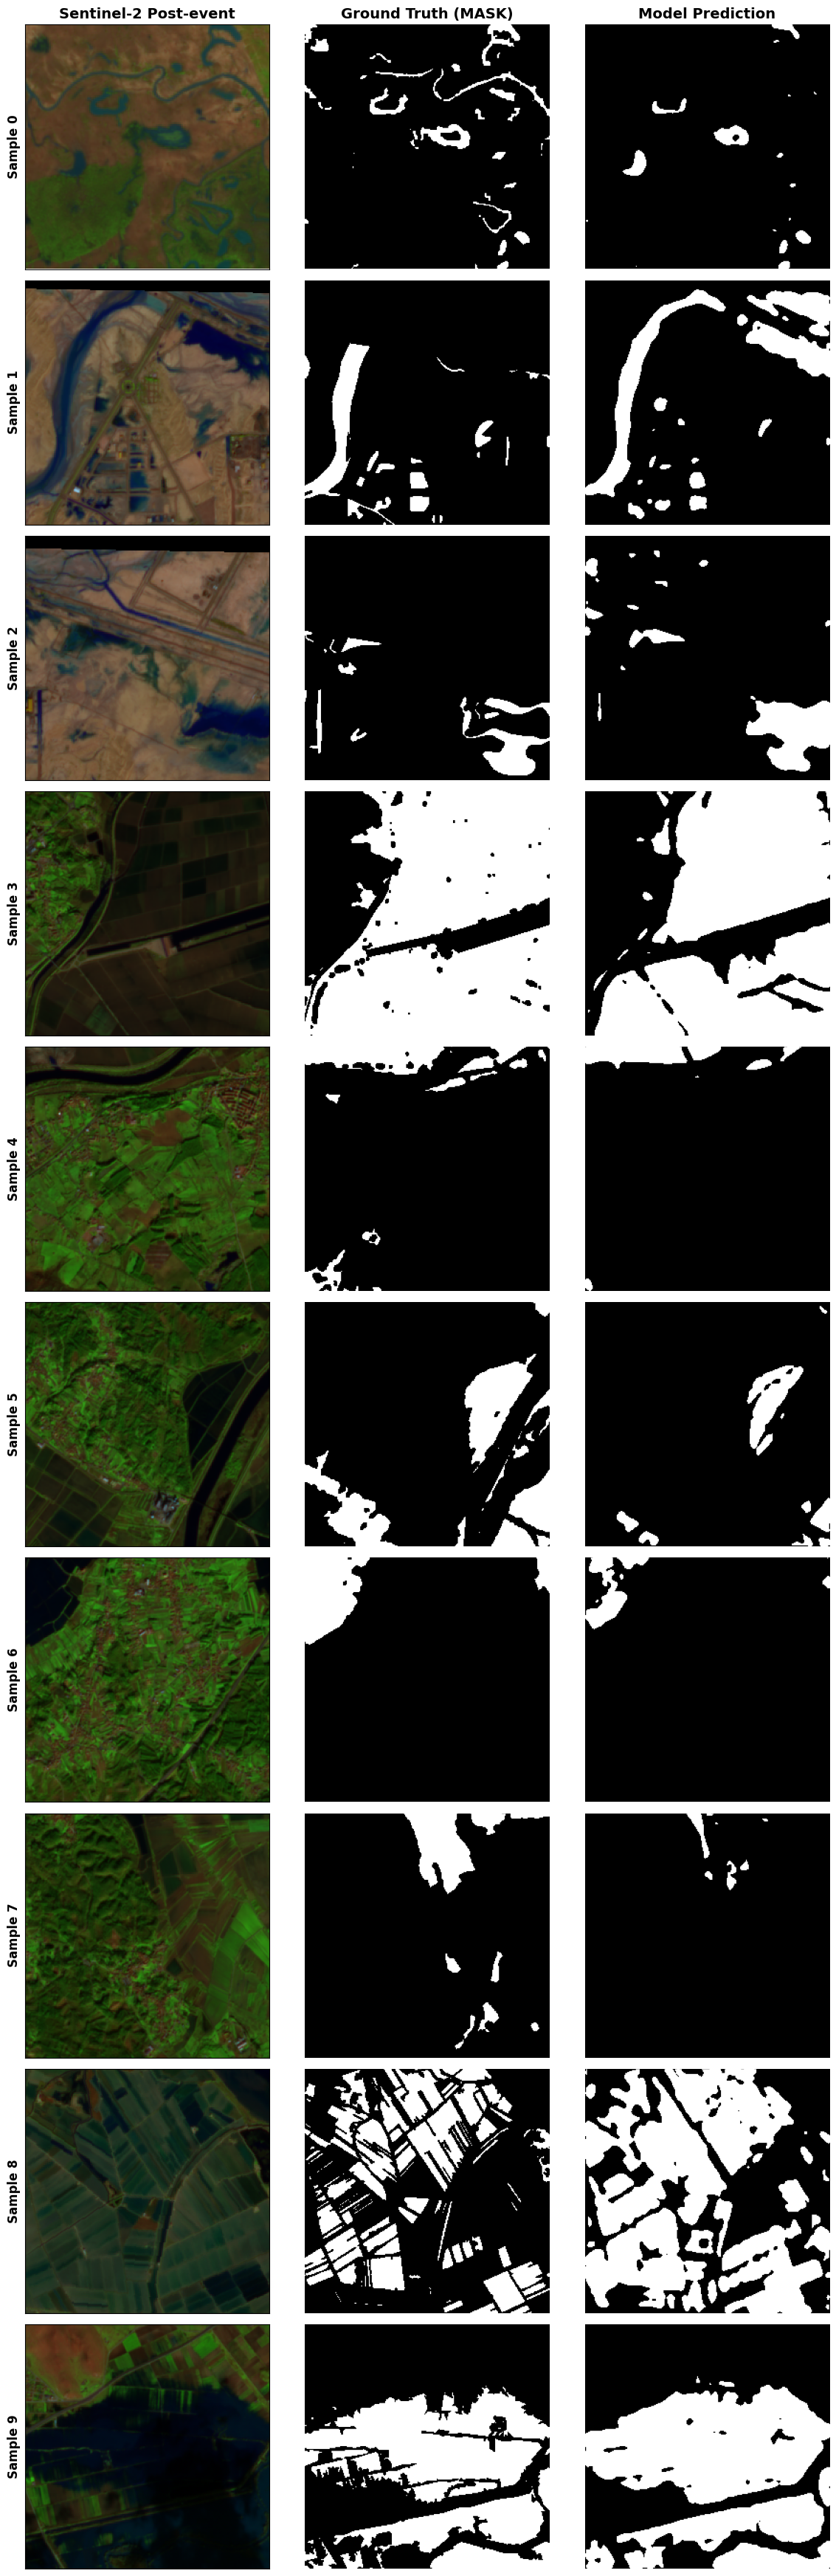

In [7]:

# 1. Set device and load test dataset
device = "cuda" if torch.cuda.is_available() else "cpu"
test_dataset = OmbriaDataset("OmbriaS2", "OmbriaS1", split="test", mode="multimodal")

# 2. Load model and checkpoint
model = MultimodalOmbriaNet(in_ch_s2=3, in_ch_s1=1)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# 3. Choose 10 test image indices to visualize (first 10 samples)
indices = list(range(10)) 

# 4. Set up the plotting grid (10 rows, 3 columns)
fig, axes = plt.subplots(10, 3, figsize=(12, 35))

for i, idx in enumerate(indices):
    inputs, mask = test_dataset[idx]
    
    # Make prediction
    with torch.no_grad():
        inputs_device = [x.unsqueeze(0).to(device) for x in inputs]
        output = model(*inputs_device)
        pred_mask = (output > 0.5).cpu().numpy().squeeze()
        
    s2_after_img = inputs[0].numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy().squeeze()
    
    # Column 1: Input image
    axes[i, 0].imshow(s2_after_img)
    if i == 0:
        axes[i, 0].set_title("Sentinel-2 Post-event", fontsize=14, fontweight="bold")
    axes[i, 0].set_ylabel(f"Sample {idx}", fontsize=12, fontweight="bold")
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    
    # Column 2: Ground Truth
    axes[i, 1].imshow(gt_mask, cmap="gray")
    if i == 0:
        axes[i, 1].set_title("Ground Truth (MASK)", fontsize=14, fontweight="bold")
    axes[i, 1].axis("off")
    
    # Column 3: Model Prediction
    axes[i, 2].imshow(pred_mask, cmap="gray")
    if i == 0:
        axes[i, 2].set_title("Model Prediction", fontsize=14, fontweight="bold")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("10_samples_comparison.png", dpi=150)
plt.show()
